In [2]:
# Box model written by Neosha after Brinkerhoff (2016)
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Now code up equations 7 and 8

def rhs(t, state, Q_in_func, k_hat, gamma, psi, r_hat, chi, pi, alpha, beta, n=3):

    A_hat, P_hat = state

    # Enforce physical bounds
    A_hat = max(A_hat, 0.0)
    P_hat = np.clip(P_hat, 0.0, 1.0)

    eps = 1e-6
    effective_pressure = max(1.0 - P_hat, eps)  # prevents singularity
    
    # Equation 7
    sliding_opening = k_hat/((1-P_hat)**gamma)
    melting_opening = psi * r_hat * A_hat**alpha * P_hat**beta
    creep_closure = A_hat * (1 - P_hat)**n

    dA_dt = sliding_opening + melting_opening - creep_closure

    # Equation 8 (differs from Claude version)
    dP_dt = chi*(Q_in_func(t) - r_hat * A_hat**alpha * P_hat**(beta-1) - pi*dA_dt)

    return dA_dt, dP_dt

In [4]:
# Initial values from MCMC
'''
A0_hat = 0.9 # Initial cavity size (defined with MCMC)
P0_hat = 0.2 # Initial pressure (defined MCMC)
k_hat = 0.44 # Basal traction coefficient
r_hat = 0.02 # linear flux coefficient


Pi = 0.09 # From Bartholomaus et al. 
Psi = 0.018 # From Bartholomaus et al. 
Chi = 3.41 # Englacial storage coefficient from Bartholomaus
gamma = 0.22 # nonlinear dependence of sliding speed on effective pressure
alpha = 5/4
beta = 3/2
'''


A0_hat = 0.9
P0_hat = 0.2
k_hat  = 0.44
r_hat  = 0.02
Pi     = 0.09 #0.44   # was 0.09
Psi    =  0.018 #0.61   # was 0.018
Chi    = 0.11   # 3.41 # was 0.11  
gamma  =  0.4 # 0.4    # was 0.22 #  <--- model stability is sensitive to this! 
alpha  = 5/4   # was 5/4
beta   = 3/2   # was 3/2

In [5]:
def solve(t_span, t_eval, Q_in_func):
    params = dict(
        Q_in_func=Q_in_func,
        k_hat=k_hat, gamma=gamma, psi=Psi, r_hat=r_hat,
        chi=Chi, pi=Pi, alpha=alpha, beta=beta, n=3
    )
    solution = solve_ivp(
        fun = lambda t, y: rhs(t, y, **params),  # y = state
        t_span = t_span,
        t_eval = t_eval,
        y0 = [A0_hat, P0_hat],
        method = "RK45", # Runge Kutta,
        max_step=0.05,
        rtol=1e-6,
        atol=1e-8,
    )

    # Calculate values
    A_hat = solution.y[0]
    P_hat = np.clip(solution.y[1], 0.0, 1.0)
    Q_out = r_hat * A_hat**alpha * P_hat**(beta-1)
    cavitation = k_hat/(1-P_hat)**gamma
    print(solution.status)

    
    return solution.t, A_hat, P_hat, Q_out, cavitation

## Generate flood with different shapes of outburst impulse

In [12]:
def make_synthetic_Q_in(t_flood, flood_magnitude, flood_width):
    """
    Simple synthetic forcing: diurnal oscillation on a slow seasonal ramp,
    plus a single outburst flood pulse

    All times are nondimensional.
    """
    def Q_in_normal(t):
        #seasonal = 0.5 + 0.5 * (t / 50.0)           # slow ramp up
        seasonal = 0.5 
        diurnal  = 0.4 * np.sin(2 * np.pi * t)       # ~1 nondim day period
        flood    = flood_magnitude * np.exp(
                       -((t - t_flood) ** 2) / (2 * flood_width ** 2)) # normal curve centered about mean t_flood

        #total_Q = seasonal+diurnal+flood
        total_Q = seasonal + flood
        return max(total_Q, 0.0)

    def Q_in_longleadup(t):
         # Find the flood definition from matlab SHAKTI and put in here.
        falling_width = flood_width/10

        a = flood_magnitude/flood_width
        seasonal = 0.5

        if t > t_flood and t <= t_flood + flood_width:
            Q = seasonal + a*(t-t_flood)
        elif t > t_flood + flood_width and t <= t_flood + flood_width + falling_width:
            b = -flood_magnitude/falling_width
            Q = seasonal + b*(t-(t_flood + flood_width)) + flood_magnitude
        else:
            Q = seasonal
         
        return max(Q, 0.0)

    return Q_in_normal
    #return Q_in_longleadup

In [30]:
t_start, t_end = 0.0, 200.00
t_eval = np.linspace(t_start, t_end, 5000)


# DEFINE FLOOD PARAMS!!! 
'''
# FOR LONG LEADUP:
t_flood=100
flood_magnitude=3.0
flood_width=50
'''

# FOR NORMAL CURVE:
t_flood = 100
flood_magnitude = 5.0
flood_width = 0.1

Q_in_func = make_synthetic_Q_in(t_flood, flood_magnitude, flood_width)

times, A_hat, P_hat, Q_out, cavitation = solve(
    t_span=(t_start, t_end),
    t_eval = t_eval,
    Q_in_func=Q_in_func
)

0


In [31]:
# Calculate pressure deficit

t_pre = t_flood - 1
t_post = t_flood + int(flood_width) + 8
P_pre = P_hat[t_pre]
P_post = P_hat[t_post]

P_deficit = P_pre/P_post
P_deficit

np.float64(0.9574453285893457)

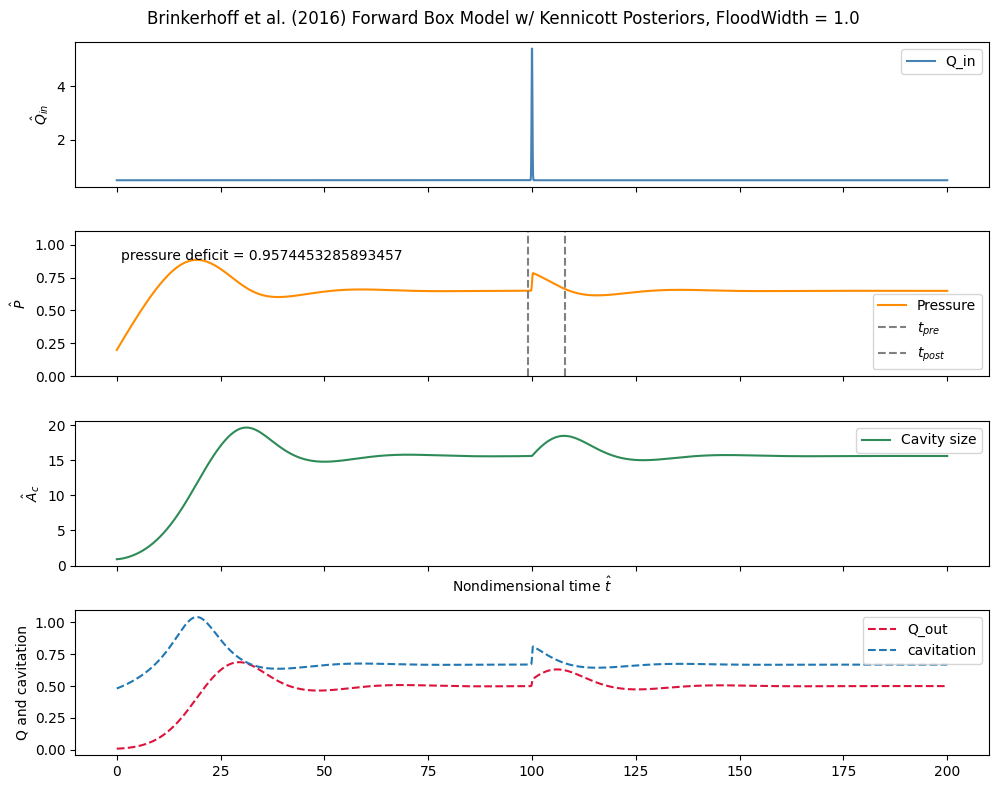

In [32]:
t = times

Q_in_vals = np.array([Q_in_func(ti) for ti in t])

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, Q_in_vals, label="Q_in", color="steelblue")
axes[0].set_ylabel("$\\hat{Q}_{in}$")
axes[0].legend();

axes[1].plot(t, P_hat, label="Pressure", color="darkorange")
axes[1].set_ylabel("$\\hat{P}$")
axes[1].set_ylim(0, 1.1)
axes[1].axvline(t_pre, label = "$t_{pre}$", color="gray", linestyle="--")
axes[1].axvline(t_post, label = "$t_{post}$", color = "gray", linestyle="--")
axes[1].text(0.05, 0.8, "pressure deficit = " + str(P_deficit), transform=axes[1].transAxes)# Places text in the top-left corner
axes[1].legend();

axes[2].plot(t, A_hat, label="Cavity size", color="seagreen")
axes[2].set_ylabel("$\\hat{A}_c$")
axes[2].set_xlabel("Nondimensional time $\\hat{t}$")
axes[2].legend(); 

axes[3].plot(t, Q_out, label="Q_out", color="crimson", linestyle="--")
axes[3].plot(t, cavitation, label = "cavitation", linestyle='--')
axes[3].set_ylabel("Q and cavitation")
axes[3].legend();

fig.suptitle("Brinkerhoff et al. (2016) Forward Box Model w/ Kennicott Posteriors, FloodWidth = 1.0")
plt.tight_layout()